# Training a graph neural network to predict alloy work functions

Included here is a dataset containing DFT computed work functions of 2x2x4 slabs, withing the Ag-Au-Pd-Pt composition space.
Work function is the energy needed to pull an electron out of the metal bulk into vacuum (about 4 Å from the surface).
It depends on the metals present and their arrangment, hence the use of graphs, rather than a tree, for example. The graphs
we generate for the dataset contains the target value (work function) for each slab, and the arrangment of them (atom 1 sits
next to atoms 2,3,4,5, and such). Different GNN models include different levels of information. A base one might just contain
the list of elements, but no distances or other information, just a list of them, while other will contain distances (edges)
and/or angles and other geometric information. 

The notebook contains code ready to run, that you can read through, and at the end there is a "playground", where you can try
out different models, and see how they compare.

We will use a similar set up for the final project itself, predicting atomic magnetic moments, but on a larger dataset (it
will therefore be run on Steno, so GPUs can be used for the model training).

## Dependencies

This notebook is self-contained. The cell below installs the packages it needs (PyTorch, PyTorch Geometric, ASE, networkx, matplotlib) and downloads the dataset from the GitHub repository if it is not already next to the notebook. It runs anywhere -- Jupyter, Google Colab, or your own laptop -- and does nothing if everything is already present. Run it once, then continue top to bottom.

In [9]:
import importlib.util
import io
import shutil
import subprocess
import sys
import urllib.request
import zipfile
from pathlib import Path

REPO_ZIP = ("https://github.com/zliasi/appliedml-finalproject/"
            "archive/refs/heads/main.zip")

# install any Python packages that are not already available
required = {"torch": "torch", "torch_geometric": "torch_geometric",
            "ase": "ase", "networkx": "networkx", "matplotlib": "matplotlib"}
missing = [pip_name for module, pip_name in required.items()
           if importlib.util.find_spec(module) is None]
if missing:
    print("installing:", ", ".join(missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                   check=True)

# make sure the dataset is here. If not, download and unzip it from the repo
if not Path("dataset").exists():
    print("downloading dataset from GitHub...")
    blob = urllib.request.urlopen(REPO_ZIP).read()
    with zipfile.ZipFile(io.BytesIO(blob)) as archive:
        archive.extractall("_repo")
    # the zip unpacks to _repo/<reponame>-main/tutorial/dataset
    next(Path("_repo").glob("*/tutorial/dataset")).rename("dataset")
    shutil.rmtree("_repo", ignore_errors=True)

print("setup complete. dataset/ is ready")

setup complete. dataset/ is ready


## 0. Setup

The cell below imports the libraries we use, picks a GPU if one is available (leftover code), and sets a plotting style for the rest of the notebook

In [10]:
import json
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from ase.io import read
from ase.data import chemical_symbols
from ase.neighborlist import neighbor_list
from ase import Atoms

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import CGConv, global_mean_pool

print("torch          ", torch.__version__)
print("torch_geometric", torch_geometric.__version__)

# train on a GPU if one is visible, otherwise the CPU (this dataset is small
# enough that the CPU is perfectly fine)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device         ", DEVICE)

# fix every random seed so that re-running the notebook gives the same numbers
torch.manual_seed(0)
np.random.seed(0)

# the data folder sits next to this notebook
DATA_DIR = Path("dataset")
assert DATA_DIR.exists(), "dataset/ not found; run the Dependencies cell above first"

# plot configs
PLOT_BLUE = "#1065ab"
PLOT_RED = "#b31529"
# one colour per metal
ELEMENT_COLORS = {"Ag": "#bfbfbf", "Au": "#ffd123", "Pd": "#006985",
                  "Pt": "#d0d0e0", "H": "#ffffff"}


def apply_plot_style() -> None:
    """Set clean matplotlib defaults: small font, thin axes."""
    mpl.rcParams.update({
        "font.size": 8,
        "axes.linewidth": 0.8,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.dpi": 130,
    })


def style_axes(ax) -> None:
    """Ticks pointing inward on all four sides of the plot."""
    ax.tick_params(axis="both", top=True, right=True, direction="in")


apply_plot_style()

torch           2.8.0+cu128
torch_geometric 2.6.1
device          cpu


## 1. Look at the data first

Rule one of machine learning: always look at your data before modeling it (this data has already been checked, but we might as well establish the fundamental rules)

Our labels live in `dataset/work-functions.json`. The structures (the actual atom positions) live as ASE trajectory files under `dataset/slabs/`.

Let's load the labels and see what one entry looks like.

In [11]:
with open(DATA_DIR / "work-functions.json") as f:
    wf_data = json.load(f)

print(f"Number of distinct compositions: {len(wf_data)}")

# Print one entry to understand the structure of the file.
first_comp = list(wf_data)[4]   # a mixed Ag/Au composition
print("\nExample composition id:", first_comp)
print(json.dumps(wf_data[first_comp], indent=2)[:600], "...")

Number of distinct compositions: 199

Example composition id: ag012-au088
{
  "composition": {
    "Ag": 0.125,
    "Au": 0.875
  },
  "variants": {
    "variant-00001": {
      "wf_top_ev": 5.014982
    },
    "variant-00002": {
      "wf_top_ev": 4.836819
    },
    "variant-00003": {
      "wf_top_ev": 4.96205
    },
    "variant-00004": {
      "wf_top_ev": 4.85318
    },
    "variant-00005": {
      "wf_top_ev": 5.022617
    },
    "variant-00006": {
      "wf_top_ev": 5.026402
    }
  },
  "wf_linear_combo_ev": 4.914708
} ...


Reading that entry:

- the key, e.g., `ag012-au088`, is a composition ID -- here 12.5% silver and 87.5% gold
- `composition` gives the exact element fractions
- `variants` are different atomic arrangements of the same composition. Same recipe, atoms shuffled into different positions and, importantly, they have different work functions. This is exactly the structure-dependence we want the GNN to learn
- each variant stores `wf_top_ev`: the work function 4 Å from the top surface, in eV. This is the target number we will predict with the GNN

Now let's flatten this into a simple list of `(structure file, work function)` pairs. We also apply a small quality filter: drop any variant with a work function below 4.0 eV (to filter out any unphysical outliers). All the structures here are fine, but again, it is good to keep using robost methods and approaches, instead of only applying them when you think you need them.

In [4]:
WF_MIN_EV = 4.0   # quality cut: discard a any unphysical low outliers

samples = []   # each item: dict with comp_id, variant, traj path, target
n_total = 0
for comp_id, entry in wf_data.items():
    for variant_name, variant in entry["variants"].items():
        n_total += 1
        wf = float(variant["wf_top_ev"])
        if wf < WF_MIN_EV:
            continue
        traj_path = DATA_DIR / "slabs" / comp_id / f"{variant_name}.traj"
        samples.append({
            "comp_id": comp_id,
            "variant": variant_name,
            "traj_path": traj_path,
            "wf": wf,
        })

print(f"{n_total} variants in file, {len(samples)} kept after the 4.0 eV cut")

876 variants in file, 876 kept after the 4.0 eV cut


How are the work functions distributed? A histogram tells us the range the model has to cover and whether the values are reasonable.

work function (eV): min=4.25  max=5.57  mean=5.04


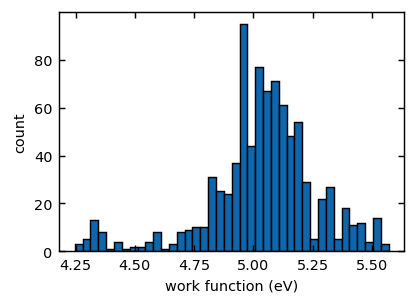

In [12]:
# pull out every work function value and summarise its range
wf_values = np.array([s["wf"] for s in samples])
print(f"work function (eV): min={wf_values.min():.2f}  "
      f"max={wf_values.max():.2f}  mean={wf_values.mean():.2f}")

# a histogram shows the spread of values the model has to learn to cover
fig, ax = plt.subplots(figsize=(3.25, 2.4))
ax.hist(wf_values, bins=40, facecolor=PLOT_BLUE, edgecolor="black", linewidth=0.8)
ax.set_xlabel("work function (eV)")
ax.set_ylabel("count")
style_axes(ax)
plt.tight_layout()
plt.show()

### The data in composition space (the simplex view)

Each structure is an alloy of up to four metals, so its composition is a point in a 3D simplex: a tetrahedron whose four corners are the pure metals Ag, Au, Pd, Pt.

Drawing every composition as a point shows how well the dataset covers the space. Every composition is drawn as a single-colour point inside the tetrahedron frame.

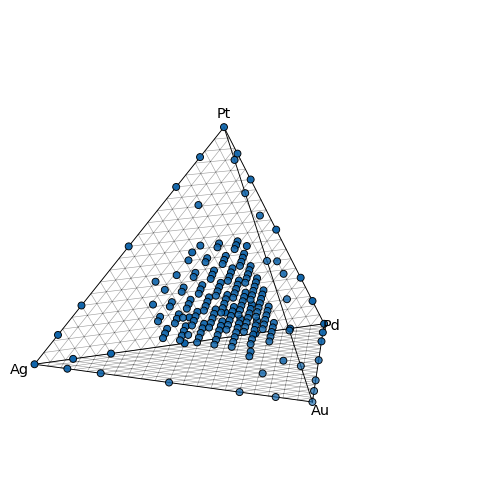

In [13]:
import itertools
import matplotlib.tri as mtri
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3d plots)

ELEMENTS = ["Ag", "Au", "Pd", "Pt"]
SIMPLEX_COLOR = "#1065ab"   # one colour for every point
GRID_RESOLUTION = 20        # how fine the grid drawn on the faces is
VIEW_ELEV, VIEW_AZIM = 10.0, 300.0


class Simplex3D:
    """Quaternary simplex (tetrahedron) for four-component compositions."""

    def __init__(self) -> None:
        # the four corners of the tetrahedron, one per metal
        self.vertices = np.array([
            [0.0, 0.0,            0.0],
            [1.0, 0.0,            0.0],
            [0.5, np.sqrt(3) / 2, 0.0],
            [0.5, 0.28867513,     0.81649658],
        ])

    def to_coordinates(self, compositions: np.ndarray) -> np.ndarray:
        """Turn composition fractions into 3D points inside the tetrahedron."""
        return compositions @ self.vertices

    def draw_frame(self, ax, labels: list[str]) -> None:
        """Draw the tetrahedron edges, a faint grid on two faces, and labels."""
        # the six edges of the tetrahedron, in thin black
        for corner_a, corner_b in itertools.combinations(self.vertices, 2):
            line = np.vstack((corner_a, corner_b)).T
            ax.plot3D(line[0], line[1], line[2], color="black", linewidth=0.5)

        # choose the bottom face and the face pointing away from the camera, and
        # draw a light triangular grid on them so the shape reads as 3D
        elev, azim = np.deg2rad(ax.elev), np.deg2rad(ax.azim)
        view = np.array([np.cos(elev) * np.sin(azim),
                         np.cos(elev) * np.cos(azim), np.sin(elev)])
        faces = [[0, 1, 2], [0, 1, 3], [1, 2, 3], [0, 2, 3]]
        normals = np.array([
            np.cross(self.vertices[b] - self.vertices[a],
                     self.vertices[c] - self.vertices[a])
            for a, b, c in faces])
        grid_faces = {0, int(np.argmin(normals @ view))}

        # a triangular grid of points in barycentric (fraction) coordinates
        bary = np.array([
            [i / GRID_RESOLUTION, j / GRID_RESOLUTION,
             (GRID_RESOLUTION - i - j) / GRID_RESOLUTION]
            for i in range(GRID_RESOLUTION + 1)
            for j in range(GRID_RESOLUTION + 1 - i)])
        flat = bary @ np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3) / 2]])
        triangulation = mtri.Triangulation(flat[:, 0], flat[:, 1])
        for face in grid_faces:
            coords = bary @ self.vertices[faces[face]]
            for tri_pts in triangulation.triangles:
                loop = coords[[tri_pts[0], tri_pts[1], tri_pts[2], tri_pts[0]]]
                ax.plot3D(loop[:, 0], loop[:, 1], loop[:, 2],
                          color="k", alpha=0.2, linewidth=0.33)

        # push the corner labels slightly outward so they stay readable
        centroid = self.vertices.mean(axis=0)
        for label, corner in zip(labels, self.vertices):
            outward = corner + 0.08 * (corner - centroid)
            ax.text(*outward, label, fontsize=8, ha="center", va="center")


# one point per composition: its Ag, Au, Pd, Pt fractions
fractions = np.array([[entry["composition"].get(el, 0.0) for el in ELEMENTS]
                      for entry in wf_data.values()])

simplex = Simplex3D()
points = simplex.to_coordinates(fractions)

fig = plt.figure(figsize=(3.8, 3.8))
ax = fig.add_subplot(111, projection="3d")
ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)
ax.set_axis_off()
simplex.draw_frame(ax, ELEMENTS)

# fade points that sit further from the camera so the cloud reads as 3D:
# build one RGBA colour per point, all the same blue, alpha set by depth
elev, azim = np.deg2rad(VIEW_ELEV), np.deg2rad(VIEW_AZIM)
view = np.array([np.cos(elev) * np.sin(azim),
                 np.cos(elev) * np.cos(azim), np.sin(elev)])
depth = points @ view
depth = (depth - depth.min()) / (np.ptp(depth) + 1e-9)
rgba = np.tile(mcolors.to_rgba(SIMPLEX_COLOR), (len(points), 1))
rgba[:, 3] = 0.65 + 0.35 * depth

ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=rgba, s=15,
           edgecolors="k", linewidths=0.5, depthshade=False)
ax.set_box_aspect(None, zoom=1.2)
plt.tight_layout()
plt.show()

### Looking at one actual structure

Each `.traj` file holds the 3D positions of every atom in a slab, plus the periodic box (the slab repeats infinitely sideways -- it is a surface, not a finite cluster). Let's load one and inspect it.

In [14]:
example = samples[300]
atoms = read(example["traj_path"])

print("composition id :", example["comp_id"])
print("work function  :", example['wf'], "eV")
print("number of atoms:", len(atoms))
print("elements       :", set(atoms.get_chemical_symbols()))
print("periodic?      :", atoms.pbc, "  (repeats in x,y; vacuum in z)")
print("\nfirst 5 atoms (element, x, y, z):")
for z, pos in list(zip(atoms.get_atomic_numbers(), atoms.get_positions()))[:5]:
    print(f"  {chemical_symbols[z]:2s}  {pos[0]:6.2f} {pos[1]:6.2f} {pos[2]:6.2f}")

composition id : ag012-au019-pd019-pt050
work function  : 5.101755 eV
number of atoms: 16
elements       : {'Pd', 'Ag', 'Pt', 'Au'}
periodic?      : [ True  True False]   (repeats in x,y; vacuum in z)

first 5 atoms (element, x, y, z):
  Pd    0.00   0.01   9.98
  Pt    2.87  -0.02  10.08
  Pd    1.45   2.49  10.05
  Pd    4.29   2.49  10.05
  Pt    1.41   0.84  12.30


## 2. Turn one structure into a graph

This is the key idea of the whole notebook, so we go slowly.

A GNN cannot read a `.traj` file directly. We must convert each structure into a
**graph** made of:

| graph piece | what it is here | stored as |
|---|---|---|
| **nodes** | the atoms | one number per atom: its atomic number (Ag=47, Au=79, ...) |
| **edges** | pairs of atoms closer than a cutoff distance | a list of (atom_i, atom_j) index pairs |
| **edge features** | how far apart each connected pair is | the distance in angstroms |
| **target `y`** | the label for the whole graph | the work function (eV) of the slab |

We connect two atoms with an edge if they are within a **cutoff radius** of each other. We use 6 angstroms here. Bigger cutoff = more edges = each atom "sees" further, but more compute. 6 Å is a good default for metals (covers a couple of neighbour shells).

We use ASE's `neighbor_list`, which correctly handles the periodic box (an atom near the edge of the cell is a neighbour of atoms on the opposite side).

In [17]:
RADIUS_CUTOFF = 6.0  # angstroms; two atoms closer than this get an edge

# neighbor_list scans the structure and finds all atom pairs within the cutoff.
# "ijd" asks for three arrays back: i = an atom, j = a neighbour of it, and
# d = the distance between them. It also wraps around the periodic box for us.
source, neighbour, distance = neighbor_list("ijd", atoms, cutoff=RADIUS_CUTOFF)

print(f"{len(atoms)} atoms  ->  {len(source)} edges within {RADIUS_CUTOFF} A")
print("\nfirst 5 edges (atom_i -> atom_j, distance):")
for atom_i, atom_j, edge_length in zip(source[:5], neighbour[:5], distance[:5]):
    print(f"  atom {atom_i:2d} -> atom {atom_j:2d}   {edge_length:.2f} A")

16 atoms  ->  672 edges within 6.0 A

first 5 edges (atom_i -> atom_j, distance):
  atom  0 -> atom  0   4.97 A
  atom  0 -> atom  8   5.78 A
  atom  0 -> atom 11   4.89 A
  atom  0 -> atom  7   4.98 A
  atom  0 -> atom  5   2.84 A


Now we package this into the object a GNN library expects. PyTorch Geometric (PyG) uses a `Data` object with these fields:

- `x`: node features, shape `[num_atoms, num_features]`. We give each atom a
  single feature: its atomic number.
- `edge_index`: the edges, shape `[2, num_edges]` (row 0 = sources, row 1 =
  destinations).
- `edge_attr`: one feature per edge, shape `[num_edges, 1]` -- the distance.
- `y`: the label for the whole graph -- the work function.

Let's write a small function that does this conversion for any structure, then run it on our example. (Kept minimal here so you can see every line.)

In [18]:
def structure_to_graph(atoms: Atoms, target: float) -> Data:
    """
    Turn one atomic structure into a graph the GNN can read.

    The graph has three parts: a number per atom (its element), a list of which
    atoms are bonded, and the length of each bond. The work function is attached
    as the label we want the model to predict.
    """
    assert len(atoms) > 0, "the structure has no atoms"

    # node feature: each atom is described by its atomic number (Ag=47, Au=79...)
    atomic_numbers = torch.tensor(atoms.get_atomic_numbers(), dtype=torch.long)

    # find the bonds (pairs within the cutoff) and their lengths
    source, neighbour, distance = neighbor_list("ijd", atoms, cutoff=RADIUS_CUTOFF)
    # edge_index lists the bonds as two rows: [from-atoms ; to-atoms]
    edge_index = torch.tensor(np.stack([source, neighbour]), dtype=torch.long)
    # edge_attr is one feature per bond, its length, shaped [num_edges, 1]
    edge_attr = torch.tensor(distance, dtype=torch.float32).unsqueeze(1)

    # y is the single target value for the whole graph
    y = torch.tensor([target], dtype=torch.float32)
    return Data(x=atomic_numbers, edge_index=edge_index, edge_attr=edge_attr, y=y)


# build the graph for our example structure and look at what came out
g = structure_to_graph(atoms, example["wf"])
print(g)
print("\nx (atomic numbers):", g.x[:8].tolist(), "...")
print("edge_index shape  :", tuple(g.edge_index.shape), "(2 rows, one column per bond)")
print("edge_attr shape   :", tuple(g.edge_attr.shape))
print("y (work function) :", g.y.item(), "eV")

Data(x=[16], edge_index=[2, 672], edge_attr=[672, 1], y=[1])

x (atomic numbers): [46, 78, 46, 46, 78, 78, 78, 78] ...
edge_index shape  : (2, 672) (2 rows, one column per bond)
edge_attr shape   : (672, 1)
y (work function) : 5.101755142211914 eV


### Seeing the graph

We just turned `atoms` into a graph `g`. Let us try to draw it the way the GNN sees it: every atom is a node (coloured by element), and every pair of atoms within the 6 angstrom cutoff is joined by an edge. We place each node at its real (x, y) position, so this picture lines up with the slab

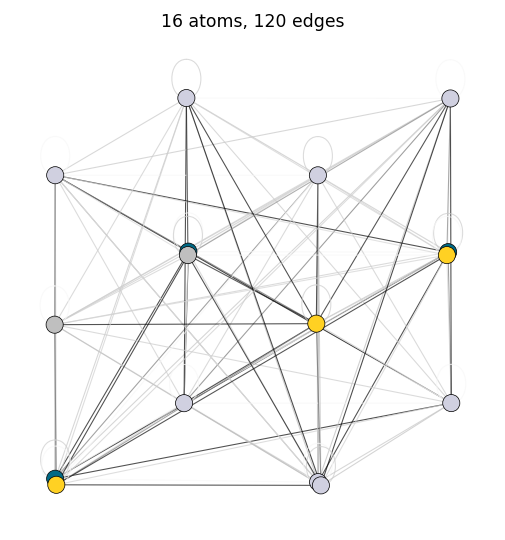

In [20]:
import networkx as nx
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# rebuild the same graph as a networkx object, which is easy to draw
nx_graph = nx.Graph()
nx_graph.add_nodes_from(range(len(atoms)))
# add each bond together with its length, so we can shade the edges by distance
for (a, b), dist in zip(g.edge_index.t().tolist(), g.edge_attr.squeeze(1).tolist()):
    nx_graph.add_edge(a, b, distance=dist)

# draw nodes at their real (x, y) positions, coloured by metal
node_positions = {i: (positions[i, 0], positions[i, 1]) for i in range(len(atoms))}
node_colors = [ELEMENT_COLORS.get(s, "#cccccc") for s in atoms.get_chemical_symbols()]

# shade edges by length: darker = shorter bond
edges = list(nx_graph.edges())
edge_dist = [nx_graph[a][b]["distance"] for a, b in edges]
norm = mcolors.Normalize(vmin=min(edge_dist), vmax=max(edge_dist))
edge_colors = [cm.Greys_r(norm(d)) for d in edge_dist]

fig, ax = plt.subplots(figsize=(4.2, 4.2))
nx.draw_networkx_edges(nx_graph, node_positions, ax=ax, edgelist=edges,
                       edge_color=edge_colors, width=0.6, alpha=0.7)
nx.draw_networkx_nodes(nx_graph, node_positions, ax=ax, node_color=node_colors,
                       edgecolors="black", linewidths=0.4, node_size=90)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(f"{nx_graph.number_of_nodes()} atoms, {nx_graph.number_of_edges()} edges")
plt.tight_layout()
plt.show()

## 3. Build the full dataset and split it properly

Now we convert every structure into a graph. There are only about 870, so we can build them all live in a minute ca. and keep them in memory.

In [21]:
# turn every structure in the dataset into a graph (a few hundred, so quick)
graphs = []
for sample in samples:
    sample_atoms = read(sample["traj_path"])          # load the structure file
    graph = structure_to_graph(sample_atoms, sample["wf"])
    graph.comp_id = sample["comp_id"]                 # remember its composition
    graphs.append(graph)

print(f"built {len(graphs)} graphs")
atom_counts = [graph.num_nodes for graph in graphs]
print(f"atoms per graph: min={min(atom_counts)} max={max(atom_counts)}")

built 876 graphs
atoms per graph: min=16 max=16


### Train / validation / test split -- and avoiding a subtle mistake

We split the data into three groups:

- **train** (~80%): the model learns from these.
- **validation** (~10%): we watch performance on these *during* training to know
  when to stop. The model never trains on them.
- **test** (~10%): touched only once, at the very end, to get an honest estimate
  of performance on unseen data.

The subtle mistake: remember that each composition (e.g. `ag012-au088`) has
several variants that are very similar to each other. If some variants of a
composition land in train and others in test, the model can "cheat" -- it has
basically seen near-identical structures already, so the test score looks better
than it really is. This is called data leakage.

The fix: split by composition, not by individual structure. All variants
of a composition go into the same split.

In [22]:
VAL_FRACTION = 0.10   # 10% of compositions held out for validation
TEST_FRACTION = 0.10  # 10% held out for the final test
SPLIT_SEED = 42

# Split by COMPOSITION, not by individual structure, to avoid leakage
composition_ids = sorted({graph.comp_id for graph in graphs})
rng = np.random.default_rng(SPLIT_SEED)
rng.shuffle(composition_ids)                      # random but reproducible order

num_val = max(1, int(VAL_FRACTION * len(composition_ids)))
num_test = max(1, int(TEST_FRACTION * len(composition_ids)))
val_comps = set(composition_ids[:num_val])
test_comps = set(composition_ids[num_val:num_val + num_test])
train_comps = set(composition_ids[num_val + num_test:])   # everything else

# sort each graph into a split based on which composition it belongs to
train_graphs = [g for g in graphs if g.comp_id in train_comps]
val_graphs = [g for g in graphs if g.comp_id in val_comps]
test_graphs = [g for g in graphs if g.comp_id in test_comps]

print(f"compositions: {len(train_comps)} train / {len(val_comps)} val / "
      f"{len(test_comps)} test")
print(f"structures  : {len(train_graphs)} train / {len(val_graphs)} val / "
      f"{len(test_graphs)} test")

compositions: 161 train / 19 val / 19 test
structures  : 702 train / 86 val / 88 test


### Standardising the target

Our work functions are around 4-6 eV. Neural networks train more smoothly when the target is centred around 0 with a spread of about 1. So we standardise: subtract the mean and divide by the standard deviation.

Crucial detail: we compute the mean and std from the training set only, then apply the same numbers to val and test. Using the test set's statistics would be another form of leakage. We will convert predictions back to eV at the end.

In [23]:
train_targets_ev = torch.tensor([g.y.item() for g in train_graphs])
TARGET_MEAN_EV = train_targets_ev.mean().item()
TARGET_STD_EV = train_targets_ev.std().item()
print(f"train mean = {TARGET_MEAN_EV:.3f} eV,  train std = {TARGET_STD_EV:.3f} eV")


def standardise_targets(graph_list: list[Data]) -> None:
    """Rescale each graph's target in place to zero mean and unit spread."""
    assert TARGET_STD_EV > 0, "the targets have no spread to scale by"
    for graph in graph_list:
        graph.y = (graph.y - TARGET_MEAN_EV) / TARGET_STD_EV


for split_graphs in (train_graphs, val_graphs, test_graphs):
    standardise_targets(split_graphs)


def to_ev(values: torch.Tensor) -> torch.Tensor:
    """Undo the standardisation, turning model numbers back into eV."""
    return values * TARGET_STD_EV + TARGET_MEAN_EV

train mean = 5.042 eV,  train std = 0.236 eV


### Batching with a DataLoader

We rarely feed one graph at a time -- it is slow and the gradient updates are noisy. Instead we group graphs into mini-batches. PyG's `DataLoader` is clever: it glues several graphs into one big disconnected graph and adds a `batch` vector that records which atom belongs to which original graph. That `batch` vector is what lets us later pool each graph back into a single prediction.

We shuffle the training data every epoch (so the model does not memorise an order) but not val/test.

In [24]:
BATCH_SIZE = 32

# A DataLoader serves the graphs in shuffled mini-batches. PyTorch Geometric
# glues the graphs of a batch into one big graph and records which atom belongs
# to which graph, so we can still get one prediction per structure at the end.
train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_graphs, batch_size=BATCH_SIZE)

# peek at one batch
batch = next(iter(train_loader))
print(batch)
print(f"this batch holds {batch.num_graphs} structures and "
      f"{batch.num_nodes} atoms in total")

DataBatch(x=[512], edge_index=[2, 21490], edge_attr=[21490, 1], y=[32], comp_id=[32], batch=[512], ptr=[33])
this batch holds 32 structures and 512 atoms in total


## 4. Build the GNN

Now the model itself. Our GNN has four stages. Here is the intuition before the
code:

1. **Embedding.** An atomic number (47, 79, ...) is just an id, not a meaningful quantity. We replace each atom's number with a learnable vector of length `HIDDEN` -- a richer description the network can shape during training. Think of it as giving each element its own learnable "fingerprint".

2. **Message passing (the GNN core).** This is what makes it a *graph* network. In each layer, every atom looks at its neighbours, gathers information from them (weighted by how far away they are -- that is where `edge_attr` comes in), and updates its own vector. Stack a few layers and an atom's vector comes to summarise its whole local environment -- which elements surround it and at what distances. We use **CGConv**, a message-passing layer designed for crystals. After 3 layers, each atom "knows about" neighbours up to 3 hops away.

3. **Pooling.** We now have one vector per atom, but we need one prediction per *structure*. So we average all the atom vectors in a graph into a single graph vector. (We use the `batch` vector here to average within each graph.)

4. **Readout.** A small ordinary neural network (an MLP) maps that graph vector to one number: the predicted (standardised) work function.

Here it is in code.

In [25]:
EMBEDDING_TABLE_SIZE = 100  # big enough for any element (our largest is Au, 79)
EDGE_FEATURE_DIM = 1        # each edge carries one number: the bond distance
DEFAULT_HIDDEN_DIM = 64     # length of each atom's feature vector
DEFAULT_NUM_LAYERS = 3      # how many message-passing rounds


class WorkFunctionGNN(nn.Module):
    """
    A small graph neural network that predicts work function.

    It works in four steps: (1) turn each atomic number into a learnable vector,
    (2) let atoms exchange information with their neighbours a few times,
    (3) average the atom vectors into one vector per structure, and (4) map that
    to a single number.
    """

    def __init__(self, hidden_dim: int = DEFAULT_HIDDEN_DIM,
                 num_layers: int = DEFAULT_NUM_LAYERS) -> None:
        """Create the layers (nothing is trained yet)."""
        super().__init__()
        assert hidden_dim > 0 and num_layers > 0, "sizes must be positive"

        # 1. lookup table: atomic number -> learnable vector of length hidden_dim
        self.embedding = nn.Embedding(EMBEDDING_TABLE_SIZE, hidden_dim)
        # 2. message-passing layers; CGConv mixes each atom with its neighbours,
        #    using the bond distance as the edge feature
        self.conv_layers = nn.ModuleList([
            CGConv(channels=hidden_dim, dim=EDGE_FEATURE_DIM, batch_norm=True)
            for _ in range(num_layers)
        ])
        self.activation = nn.ReLU()
        # 4. small network turning the pooled graph vector into one number
        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, data: Data) -> torch.Tensor:
        """Run a batch of graphs through the network; one value out per graph."""
        # 1. look up a vector for every atom
        atom_vectors = self.embedding(data.x)
        # 2. each layer updates an atom using its neighbours; after a few rounds
        #    every atom has gathered information about its local surroundings
        for conv in self.conv_layers:
            atom_vectors = self.activation(
                conv(atom_vectors, data.edge_index, data.edge_attr))
        # 3. average the atoms of each graph into one vector per structure
        graph_vectors = global_mean_pool(atom_vectors, data.batch)
        # 4. read out a single number per structure
        return self.readout(graph_vectors).squeeze(-1)


model = WorkFunctionGNN().to(DEVICE)
num_parameters = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nthis model has {num_parameters:,} trainable numbers (weights)")

WorkFunctionGNN(
  (embedding): Embedding(100, 64)
  (conv_layers): ModuleList(
    (0-2): 3 x CGConv(64, dim=1)
  )
  (activation): ReLU()
  (readout): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

this model has 60,929 trainable numbers (weights)


Before training, the weights are random, so predictions are meaningless. Let's confirm the model at least runs and produces one number per graph

In [26]:
# sanity check: the untrained model should at least run and give one number per
# graph (the values are meaningless until we train it)
model.eval()
with torch.no_grad():
    demo_batch = next(iter(train_loader)).to(DEVICE)
    demo_out = model(demo_batch)
print("output shape:", tuple(demo_out.shape), "(one prediction per graph)")
print("first 5 (untrained, so basically noise):", demo_out[:5].cpu().numpy().round(3))

output shape: (32,) (one prediction per graph)
first 5 (untrained, so basically noise): [220.849 374.599 236.172 270.212  32.705]


## 5. Train the model

Training is a loop. Each pass over the whole training set is one **epoch**. In each epoch, for every batch we:

1. predict the work functions,
2. measure how wrong we are with a loss function -- we use the mean absolute error (average size of the mistake),
3. compute gradients (`loss.backward()`) -- which direction to nudge each weight to reduce the loss,
4. let the optimizer (Adam) take a small step in that direction.

After each epoch we check the loss on the validation set. We keep the version of the model that did best on validation, and we stop early if validation stops improving for a while (this prevents overfitting -- memorising the training data instead of learning the general pattern).

First, two small helper functions: one to train a single epoch, one to evaluate on a loader.

In [28]:
def train_one_epoch(model: nn.Module, loader: DataLoader,
                    optimizer: torch.optim.Optimizer) -> float:
    """
    Show the model every training graph once and nudge its weights.

    For each batch we predict, measure how wrong we are, ask PyTorch for the
    gradient (which way reduces the error), and let the optimizer take a small
    step. Returns the average loss over the epoch.
    """
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()                                      # clear old gradients
        loss = torch.nn.functional.l1_loss(model(batch), batch.y)  # mean abs error
        loss.backward()                                            # compute gradients
        optimizer.step()                                           # update the weights
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader) -> float:
    """
    Measure the mean absolute error on a set of graphs, reported in eV.

    Nothing is trained here -- we only look. Predictions and targets are converted
    back from standardised units into eV so the number is easy to read.
    """
    model.eval()
    total_error = 0.0
    for batch in loader:
        batch = batch.to(DEVICE)
        error = (to_ev(model(batch).cpu()) - to_ev(batch.y.cpu())).abs()
        total_error += error.sum().item()
    return total_error / len(loader.dataset)

Now the training loop itself. With ~700 training structures this runs in a couple of minutes on CPU. Watch the validation error (in eV) decrease.

In [29]:
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-2
MAX_EPOCHS = 150
EARLY_STOP_PATIENCE = 30  # stop once val MAE has not improved for this many epochs
LOG_EVERY = 10

# start from a fresh model and an Adam optimizer (a standard, robust choice)
model = WorkFunctionGNN().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE,
                             weight_decay=WEIGHT_DECAY)

best_val_mae = float("inf")
best_state = None
epochs_since_improvement = 0
history = {"train": [], "val": []}

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer)   # learn
    val_mae = evaluate(model, val_loader)                          # check progress
    history["train"].append(train_loss)
    history["val"].append(val_mae)

    # keep a copy of the best model so far (lowest validation error)
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_since_improvement = 0
    else:
        epochs_since_improvement += 1

    if epoch == 1 or epoch % LOG_EVERY == 0:
        print(f"epoch {epoch:3d} | train {train_loss:.3f} | "
              f"val MAE {val_mae:.3f} eV | best {best_val_mae:.3f} eV")

    # stop early if it has not improved in a while (this guards against overfitting)
    if epochs_since_improvement >= EARLY_STOP_PATIENCE:
        print(f"\nstopping early at epoch {epoch}")
        break

model.load_state_dict(best_state)   # go back to the best model we saw
print(f"\nbest validation MAE: {best_val_mae:.3f} eV")

epoch   1 | train 0.514 | val MAE 0.113 eV | best 0.113 eV
epoch  10 | train 0.285 | val MAE 0.072 eV | best 0.064 eV
epoch  20 | train 0.266 | val MAE 0.058 eV | best 0.058 eV
epoch  30 | train 0.260 | val MAE 0.057 eV | best 0.056 eV
epoch  40 | train 0.254 | val MAE 0.061 eV | best 0.056 eV
epoch  50 | train 0.257 | val MAE 0.066 eV | best 0.056 eV

stopping early at epoch 56

best validation MAE: 0.056 eV


### Did it learn? Look at the training curves

Plotting the loss over epochs is the standard way to see what happened. The training loss is in standardised units and the validation error is in eV, so we
put them on separate axes. The shapes are what matter.

- Both curves dropping = the model is learning.
- Training keeps dropping while validation flattens or rises = overfitting (our early stopping guards against the worst of it).

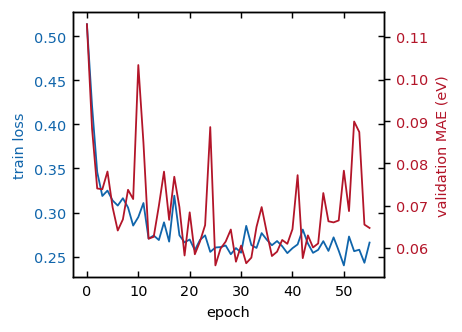

In [30]:
# the training loss (standardised units) and the validation error (eV) are on
# different scales, so each gets its own y-axis. The shapes are what matter
fig, ax_left = plt.subplots(figsize=(3.6, 2.6))
ax_left.plot(history["train"], color=PLOT_BLUE, linewidth=1.0, label="train loss")
ax_left.set_xlabel("epoch")
ax_left.set_ylabel("train loss", color=PLOT_BLUE)
ax_left.tick_params(axis="y", labelcolor=PLOT_BLUE)

ax_right = ax_left.twinx()
ax_right.plot(history["val"], color=PLOT_RED, linewidth=1.0, label="val MAE (eV)")
ax_right.set_ylabel("validation MAE (eV)", color=PLOT_RED)
ax_right.tick_params(axis="y", labelcolor=PLOT_RED)

style_axes(ax_left)
plt.tight_layout()
plt.show()

## 6. The honest test: evaluate on unseen structures

The validation set guided our early stopping, so it is no longer fully "unseen". The test set has played no role until now. Its score is our honest
estimate of how the model does on new structures.

The clearest way to show regression performance is a parity plot: predicted vs. true work function. Perfect predictions sit on the diagonal `y = x`.

In [31]:
@torch.no_grad()
def collect_predictions(model: nn.Module,
                        loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    """Run the model over a loader and return (predicted, true) arrays in eV."""
    model.eval()
    predicted, true = [], []
    for batch in loader:
        batch = batch.to(DEVICE)
        predicted.append(to_ev(model(batch).cpu()))
        true.append(to_ev(batch.y.cpu()))
    return torch.cat(predicted).numpy(), torch.cat(true).numpy()


# predictions on the test set: structures the model has never seen
predicted_ev, true_ev = collect_predictions(model, test_loader)

# three standard regression scores
test_mae = np.abs(predicted_ev - true_ev).mean()             # average error size
test_rmse = np.sqrt(((predicted_ev - true_ev) ** 2).mean())  # punishes big misses
# R^2 is the fraction of the variation the model explains (1.0 would be perfect)
residual = ((true_ev - predicted_ev) ** 2).sum()
total = ((true_ev - true_ev.mean()) ** 2).sum()
r2 = 1 - residual / total

print(f"test set: {len(true_ev)} unseen structures")
print(f"  MAE  = {test_mae:.3f} eV")
print(f"  RMSE = {test_rmse:.3f} eV")
print(f"  R^2  = {r2:.3f}")

test set: 88 unseen structures
  MAE  = 0.060 eV
  RMSE = 0.080 eV
  R^2  = 0.768


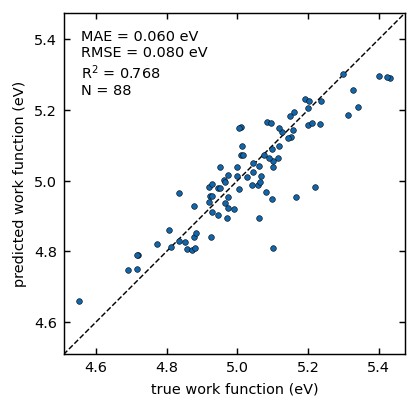

In [32]:
# Parity plot: predicted vs true. Perfect predictions land on the dashed diagonal.
fig, ax = plt.subplots(figsize=(3.25, 3.25))
ax.scatter(true_ev, predicted_ev, s=10, color=PLOT_BLUE, edgecolors="black",
           linewidths=0.3, zorder=3)

# the y = x reference line, spanning the data range with a small margin
lo = min(true_ev.min(), predicted_ev.min())
hi = max(true_ev.max(), predicted_ev.max())
margin = (hi - lo) * 0.05
limits = [lo - margin, hi + margin]
ax.plot(limits, limits, "k--", linewidth=0.8, zorder=2)
ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_box_aspect(1)

# the scores in a small rounded box in the corner
ax.annotate(f"MAE = {test_mae:.3f} eV\nRMSE = {test_rmse:.3f} eV\n"
            f"R$^2$ = {r2:.3f}\nN = {len(true_ev)}",
            xy=(0.05, 0.95), xycoords="axes fraction", va="top",
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="none",
                      alpha=0.8))
ax.set_xlabel("true work function (eV)")
ax.set_ylabel("predicted work function (eV)")
style_axes(ax)
plt.tight_layout()
plt.show()

Points hugging the dashed line are good predictions. An MAE of a few tenths of an eV from such a small model and dataset is a solid result -- it means the GNN genuinely learned how composition and atomic arrangement set the work function, not just the average value.

For reference, a trivial baseline that always predicts the mean work function would have an error roughly equal to the spread of the data. Let's confirm our model beats it.

### Where do the errors fall?

A histogram of (predicted minus true) should be a tight bump centred on zero: no big systematic bias, most predictions close to correct.

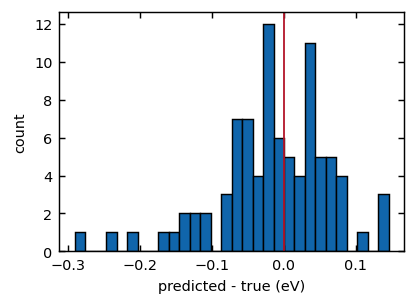

In [33]:
# the spread of errors: we want them centred on zero and tight
errors_ev = predicted_ev - true_ev
fig, ax = plt.subplots(figsize=(3.25, 2.4))
ax.hist(errors_ev, bins=30, facecolor=PLOT_BLUE, edgecolor="black", linewidth=0.8)
ax.axvline(0.0, color=PLOT_RED, linewidth=1.0)   # the zero-error line
ax.set_xlabel("predicted - true (eV)")
ax.set_ylabel("count")
style_axes(ax)
plt.tight_layout()
plt.show()

In [36]:
# is the GNN actually better than always guessing the average work function?
baseline_mae = np.abs(true_ev - TARGET_MEAN_EV).mean()
print(f"guess-the-mean baseline MAE: {baseline_mae:.3f} eV")
print(f"our GNN test MAE           : {test_mae:.3f} eV")
print(f"{baseline_mae / test_mae:.1f}x better than guessing")

guess-the-mean baseline MAE: 0.130 eV
our GNN test MAE           : 0.060 eV
2.2x better than guessing


## 7. Try other message-passing layers yourself

We used `CGConv`, but PyTorch Geometric ships dozens of graph-convolution layers, and swapping one in is almost a one-line change. Experimenting is the best way to build intuition, so treat this section as a playground.

How to find other layers: They all live in `torch_geometric.nn`. The cell below lists them, or you can browse the official GNN cheat sheet: https://pytorch-geometric.readthedocs.io/en/latest/cheatsheet/gnn_cheatsheet.html

A few worth trying:
- `GCNConv` -- the classic graph convolution (uses connectivity only, ignores distance).
- `GraphConv` / `SAGEConv` -- simple, fast neighbour aggregation.
- `GATv2Conv` -- attention: the model learns how much to weight each neighbour (pass `edge_dim=1` to feed it the bond distance).
- `TransformerConv` -- a transformer-style attention layer.

The helper below builds our model with any of these. The main thing to watch is that each layer has a slightly different call signature (some take `edge_attr`, some do not). Add an `elif` branch to `make_conv` to try your own.

In [38]:
from torch_geometric.nn import GCNConv, GATv2Conv
import torch_geometric.nn as pyg_nn

# every layer lives in torch_geometric.nn; list them so you can explore
available = [name for name in dir(pyg_nn) if name.endswith("Conv")]
print(f"{len(available)} convolution layers are available, including:")
print("GCNConv, GraphConv, SAGEConv, GATv2Conv, TransformerConv, ...\n")


def make_conv(conv_name: str, hidden_dim: int) -> nn.Module:
    """
    Build one message-passing layer of the named type.

    Each PyG layer has its own constructor, so this is the place to add a new
    'elif' branch when you want to try another one.
    """
    if conv_name == "cgconv":
        return CGConv(hidden_dim, dim=EDGE_FEATURE_DIM, batch_norm=True)
    if conv_name == "gcn":
        return GCNConv(hidden_dim, hidden_dim)
    if conv_name == "gat":
        return GATv2Conv(hidden_dim, hidden_dim, edge_dim=EDGE_FEATURE_DIM)
    raise ValueError(f"unknown conv layer: {conv_name}")


class FlexibleGNN(nn.Module):
    """The same model as before, but you choose the convolution layer."""

    def __init__(self, conv_name: str, hidden_dim: int = DEFAULT_HIDDEN_DIM,
                 num_layers: int = DEFAULT_NUM_LAYERS) -> None:
        """Build the model around the named conv layer."""
        super().__init__()
        self.conv_name = conv_name
        self.embedding = nn.Embedding(EMBEDDING_TABLE_SIZE, hidden_dim)
        self.conv_layers = nn.ModuleList(
            [make_conv(conv_name, hidden_dim) for _ in range(num_layers)])
        self.activation = nn.ReLU()
        self.readout = nn.Sequential(nn.Linear(hidden_dim, hidden_dim),
                                     nn.ReLU(), nn.Linear(hidden_dim, 1))

    def forward(self, data: Data) -> torch.Tensor:
        """One prediction per graph, exactly like WorkFunctionGNN."""
        x = self.embedding(data.x)
        for conv in self.conv_layers:
            # GCN reads only the bonds; the others also use the bond distance
            if self.conv_name == "gcn":
                x = self.activation(conv(x, data.edge_index))
            else:
                x = self.activation(conv(x, data.edge_index, data.edge_attr))
        return self.readout(global_mean_pool(x, data.batch)).squeeze(-1)


def quick_test(conv_name: str, num_epochs: int = 60) -> float:
    """Train a variant briefly and return its test MAE in eV."""
    torch.manual_seed(0)
    variant = FlexibleGNN(conv_name).to(DEVICE)
    optimizer = torch.optim.Adam(variant.parameters(), lr=LEARNING_RATE,
                                 weight_decay=WEIGHT_DECAY)
    for _ in range(num_epochs):
        train_one_epoch(variant, train_loader, optimizer)
    return evaluate(variant, test_loader)


# compare a few. Edit this list (and add branches to make_conv) to experiment
print("layer     test MAE")
for name in ["cgconv", "gcn", "gat"]:
    print(f"{name:7s}   {quick_test(name):.3f} eV")

68 convolution layers are available, including:
GCNConv, GraphConv, SAGEConv, GATv2Conv, TransformerConv, ...

layer     test MAE
cgconv    0.066 eV
gcn       0.103 eV
gat       0.091 eV


## 8. Recap and final project

This is the complete GNN pipeline: (1) look at the data, (2) turn each structure into a graph, (3) split it without leakage, (4) define a message-passing model, (5) train it with early stopping, and judge it honestly on a held-out test set.

A GNN lets each atom repeatedly share information with its neighbours, builds up a description of every atom's surroundings, then combines those into one prediction for the whole structure.

The final project (atomic magnetic moments) reuses almost all of this. The only real change is what is predicted:

- here we wanted one number per structure, so we pooled all the atom vectors into one before the readout,
- magnetic moments are one number per atom, so we skip the pooling and apply the readout to every atom vector instead. The loss is then averaged over the atoms.

Everything else -- graph building, message passing, the training loop, the plots -- carries straight over :)